# **Zadanie: przestępczość**

Import nieszbednych bibliotek

In [118]:
import pandas as pd
import gspread
from gspread_dataframe import set_with_dataframe
import missingno as msno
import numpy as np

wczytanie danych z pliku csv

In [119]:
df = pd.read_csv('fatal-police-shootings-data.csv')
print(df[['race', 'date',]].isnull().sum())
df['race'] = df['race'].fillna('Unknown')
df.head()

race    521
date      0
dtype: int64


,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [120]:
new_df = df.pivot_table(index='race', columns='signs_of_mental_illness', aggfunc='size')

In [121]:
new_df['%_mental_illness'] = new_df.apply(lambda x: ((x[True] / (x[True] + x[False]))*100), axis=1)
new_df

signs_of_mental_illness,False,True,%_mental_illness
race,,,
A,69,24,25.806452
B,1114,184,14.175655
H,745,157,17.405765
N,64,14,17.948718
O,37,11,22.916667
Unknown,408,113,21.689060
W,1763,713,28.796446


In [122]:
print(f"Najczęściej znamiona choroby psychicznej występują w rasie: {new_df['%_mental_illness'].idxmax()} i wynoszą {new_df['%_mental_illness'].max().round(2)}%")

Najczęściej znamiona choroby psychicznej występują w rasie: W i wynoszą 28.8%


In [123]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_intervention'] = df['date'].dt.day_name()
df.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,day_of_intervention
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,Friday
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,Friday
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,Saturday
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False,Sunday
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False,Sunday


In [124]:
days_count = df['day_of_intervention'].value_counts()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
days_count = days_count.reindex(order)

<Axes: title={'center': 'Liczba śmiertelnych interwencji policji w USA w zależności od dnia tygodnia'}, xlabel='Dzień tygodnia', ylabel='Liczba interwencji'>

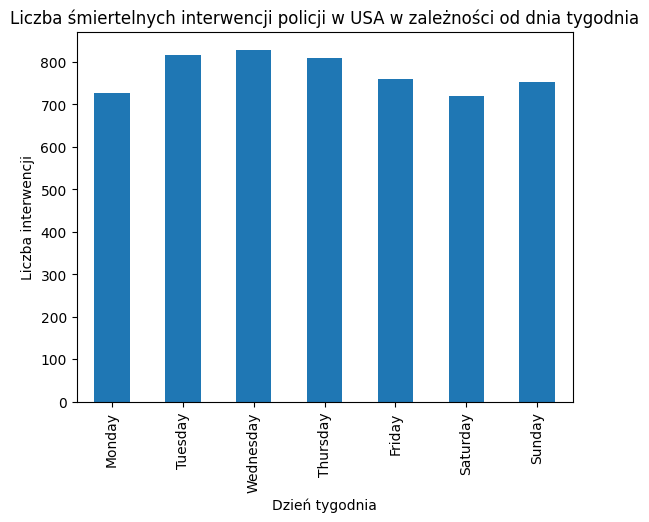

In [125]:
days_count.plot(
    kind='bar', 
    title='Liczba śmiertelnych interwencji policji w USA w zależności od dnia tygodnia',
    xlabel='Dzień tygodnia',
    ylabel='Liczba interwencji',
)


In [126]:
user_agent = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36'}

adres_url_1 = 'https://simple.wikipedia.org/wiki/List_of_U.S._states_by_population'
data = pd.read_html(adres_url_1, header=0, storage_options=user_agent)
df_state_by_population = data[0]



In [127]:
adres_url_2 = 'https://en.wikipedia.org/wiki/List_of_U.S._state_and_territory_abbreviations'
data = pd.read_html(adres_url_2, header=0, storage_options=user_agent)
df_territory_abbreviations = data[1]

In [128]:
df_territory_abbreviations.head()

,Name,Status of region,ISO,ANSI,USPS (& ANSI),USCG,GPO,AP,Court,Others
0,Name,Status of region,NaN,NaN,NaN,NaN,GPO,AP,Court,Others
1,United States of America,Federal state (not defined by USPS),US USA 840,0.0,US,NaN,U.S.,U.S.,U.S.,U.S.A.
2,Alabama,State,US-AL,1.0,AL,AL,Ala.,Ala.,Ala.,NaN
3,Alaska,State,US-AK,2.0,AK,AK,Alaska,Alaska,Alaska,Ak.[3]
4,Arizona,State,US-AZ,4.0,AZ,AZ,Ariz.,Ariz.,Ariz.,NaN


In [129]:
df_state_by_population.head()

,"Rank in states & territories, 2020","Rank in states & territories, 2010",State,"Census population, April 1, 2020 [1][2]","Census population, April 1, 2010 [1][2]","Percent change, 2010–2020 [note 1]","Absolute change, 2010-2020","Total seats in the U.S. House of Representatives, 2023–2033",Census population per electoral vote [note 2],Census population per House seat,"Percent of the total U.S. population, 2020 [note 3]"
0,1,1,California,39538223,37253956,6.1%,+2284267,52,732189,760350,11.80%
1,2,2,Texas,30145505,25145561,15.9%,+4999944,38,728638,766987,8.70%
2,3,4,Florida,21538187,18801310,14.6%,+2736877,28,717940,769221,6.43%
3,4,3,New York,20201249,19378102,4.2%,+823147,26,721473,776971,6.03%
4,5,6,Pennsylvania,13002700,12702379,2.4%,+300321,17,684353,764865,3.88%


In [144]:


state_population_df = pd.merge(
    df_territory_abbreviations[['Name', 'USPS (& ANSI)']],
    df_state_by_population[['State', 'Census population, April 1, 2020 [1][2]']], 
    left_on='Name', right_on='State',                          
    how='inner'                           
)
state_population_df = state_population_df.drop(columns='Name')
state_population_df = state_population_df.rename(columns={
    'USPS (& ANSI)': 'state', 
    'Census population, April 1, 2020 [1][2]': 'population'
})
state_population_df.head(3)

,state,State,population
0,AL,Alabama,5024279
1,AK,Alaska,733391
2,AZ,Arizona,7151502


In [143]:
df.head(3)

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,day_of_intervention
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,Friday
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,Friday
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,Saturday


In [145]:

state_incidents_df = df.pivot_table(index='state', aggfunc='size')
state_incidents_df = state_incidents_df.to_frame(name='incidents')
state_incidents_df = state_incidents_df.reset_index() 
state_incidents_df.head(3)




,state,incidents
0,AK,39
1,AL,104
2,AR,83


In [159]:
incidents_per_polulation_df = pd.merge(
    state_population_df[['state', 'State', 'population']],
    state_incidents_df[['state', 'incidents']], 
    on='state',                          
    how='inner'                           
)
incidents_per_polulation_df.head(3)

,state,State,population,incidents
0,AL,Alabama,5024279,104
1,AK,Alaska,733391,39
2,AZ,Arizona,7151502,254


In [161]:
incidents_per_polulation_df['ratio'] = incidents_per_polulation_df.apply(lambda x: (x['incidents'] / x['population']) * 1000, axis=1)
incidents_per_polulation_df

,state,State,population,incidents,ratio
0,AL,Alabama,5024279,104,0.020699
1,AK,Alaska,733391,39,0.053178
2,AZ,Arizona,7151502,254,0.035517
3,AR,Arkansas,3011524,83,0.027561
4,CA,California,39538223,799,0.020208
5,CO,Colorado,5773714,195,0.033774
6,CT,Connecticut,3605944,21,0.005824
7,DE,Delaware,989948,13,0.013132
8,DC,District of Columbia,689545,13,0.018853
9,FL,Florida,21538187,350,0.016250
